In [1]:
import sys
import importlib
import numpy as np

sys.path.append('C:/Nacho/Universidad/Prácticas Raman/LIBS_QUANTIFICATION_INTA')
from LIBS_quantification_toolbox import * 

In [2]:
wavelengths, n1, n2, n3, n4, n5, dark, nombres = cargar_espectros_5shots2_0('FinalSamples/Level0/M1/P1', 'M1_P1')

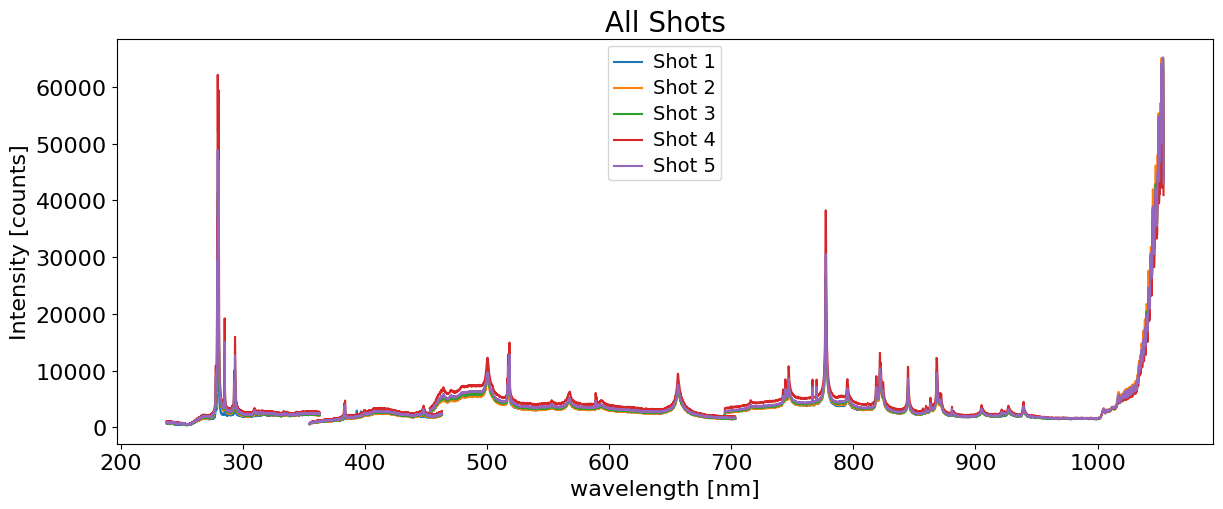

In [3]:
fig, ax = plot_spectra([wavelengths]*5, [n1, n2, n3, n4, n5], xlabel='wavelength [nm]',ylabel='Intensity [counts]', titulo= 'All Shots', no_show = True)
# Título
ax.set_title(ax.get_title(), fontsize=20)

# Etiquetas de ejes
ax.set_xlabel(ax.get_xlabel(), fontsize=16)
ax.set_ylabel(ax.get_ylabel(), fontsize=16)

# Tamaño de los ticks
ax.tick_params(axis='both', which='major', labelsize=16)

# Leyenda
leg = ax.get_legend()
if leg:
    for text in leg.get_texts():
        text.set_fontsize(14)
    leg.set_title(leg.get_title().get_text(), prop={'size':14})


In [4]:
ws, intensidades, nombres = cargar_espectros_5shotspromV2_0('FinalSamples/Level0/M1/P1', 'M1_P1')

M1_P1: utilizando 4 de 4 shots para el promedio


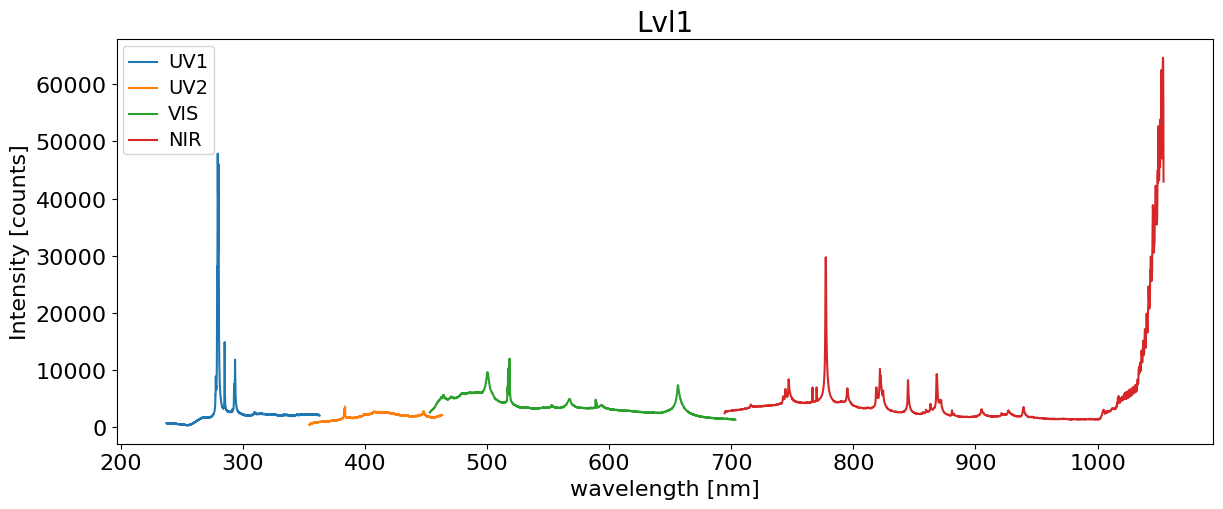

In [5]:
fig, ax = plot_spectra(ws, intensidades, xlabel='wavelength [nm]',ylabel='Intensity [counts]', nombres = nombres,  titulo= 'Lvl1', no_show = True)
# Título
ax.set_title(ax.get_title(), fontsize=20)

# Etiquetas de ejes
ax.set_xlabel(ax.get_xlabel(), fontsize=16)
ax.set_ylabel(ax.get_ylabel(), fontsize=16)

# Tamaño de los ticks
ax.tick_params(axis='both', which='major', labelsize=16)

# Leyenda
leg = ax.get_legend()
if leg:
    for text in leg.get_texts():
        text.set_fontsize(14)
    leg.set_title(leg.get_title().get_text(), prop={'size':14})


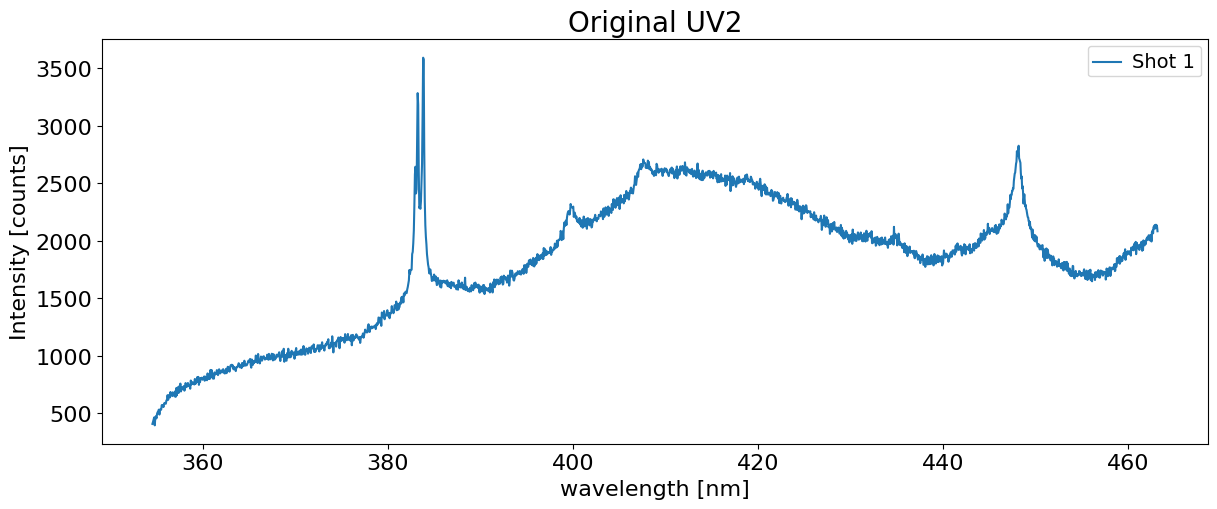

In [6]:
fig, ax = plot_spectra(ws[1], intensidades[1], xlabel='wavelength [nm]',ylabel='Intensity [counts]', titulo= 'Original UV2', no_show = True)
# Título
ax.set_title(ax.get_title(), fontsize=20)

# Etiquetas de ejes
ax.set_xlabel(ax.get_xlabel(), fontsize=16)
ax.set_ylabel(ax.get_ylabel(), fontsize=16)

# Tamaño de los ticks
ax.tick_params(axis='both', which='major', labelsize=16)

# Leyenda
leg = ax.get_legend()
if leg:
    for text in leg.get_texts():
        text.set_fontsize(14)
    leg.set_title(leg.get_title().get_text(), prop={'size':14})


In [7]:
denoised=denoise_spectra(intensidades)

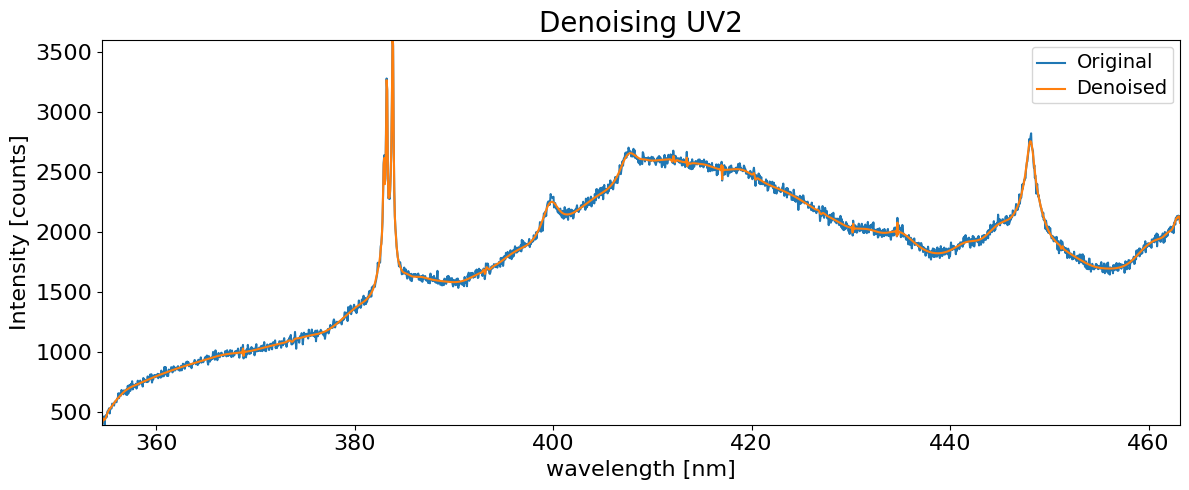

In [8]:
fig, ax = plot_spectra([ws[1]]*2, [intensidades[1],denoised[1]], xlabel='wavelength [nm]',ylabel='Intensity [counts]', nombres = ['Original','Denoised'], titulo= 'Denoising UV2', no_show = True)
# Título
ax.set_title(ax.get_title(), fontsize=20)

# Etiquetas de ejes
ax.set_xlabel(ax.get_xlabel(), fontsize=16)
ax.set_ylabel(ax.get_ylabel(), fontsize=16)

# Tamaño de los ticks
ax.tick_params(axis='both', which='major', labelsize=16)

# Leyenda
leg = ax.get_legend()
if leg:
    for text in leg.get_texts():
        text.set_fontsize(14)
    leg.set_title(leg.get_title().get_text(), prop={'size':14})
# 1) Agarrar los datos X e Y ploteados
xdata = ws[1]
ydata_orig = intensidades[1]
ydata_den  = denoised[1]

# 2) Ajustar los límites de los ejes al mínimo y máximo exactos
ax.set_xlim(xdata.min(), xdata.max())
ax.set_ylim(
    min(ydata_orig.min(), ydata_den.min()),
    max(ydata_orig.max(),  ydata_den.max())
)

# 3) Eliminar márgenes extra
ax.margins(x=0, y=0)

plt.tight_layout()
plt.show()

In [9]:
stiched = stitch_spectra(denoised, wavelengths)

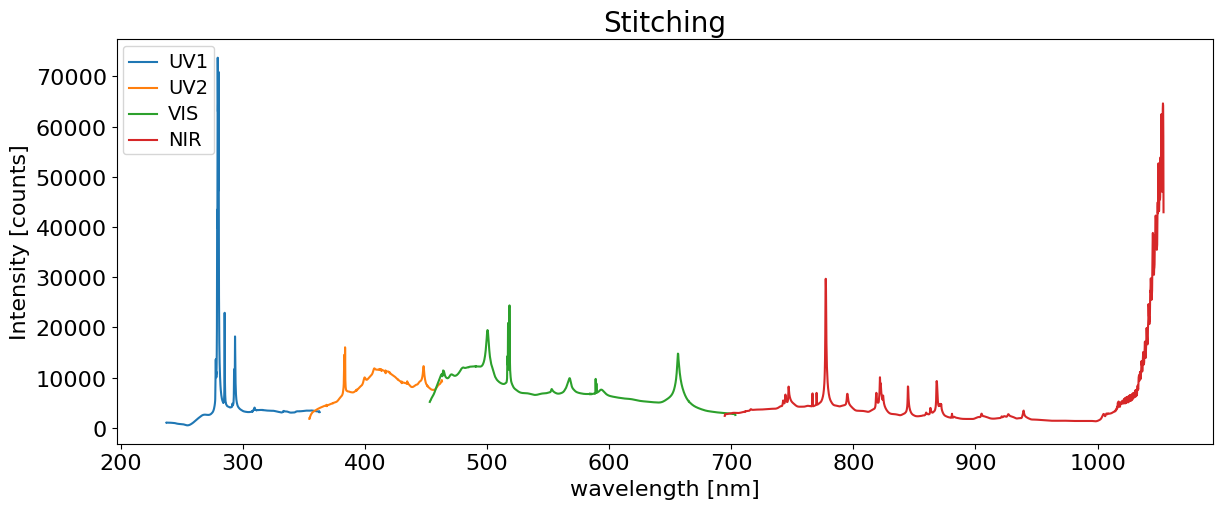

In [10]:
fig, ax = plot_spectra(ws, stiched, xlabel='wavelength [nm]',ylabel='Intensity [counts]',nombres = nombres, titulo= 'Stitching', no_show = True)
# Título
ax.set_title(ax.get_title(), fontsize=20)

# Etiquetas de ejes
ax.set_xlabel(ax.get_xlabel(), fontsize=16)
ax.set_ylabel(ax.get_ylabel(), fontsize=16)

# Tamaño de los ticks
ax.tick_params(axis='both', which='major', labelsize=16)

# Leyenda
leg = ax.get_legend()
if leg:
    for text in leg.get_texts():
        text.set_fontsize(14)
    leg.set_title(leg.get_title().get_text(), prop={'size':14})
    

In [11]:
corrected, continua = subtract_baseline(stiched)

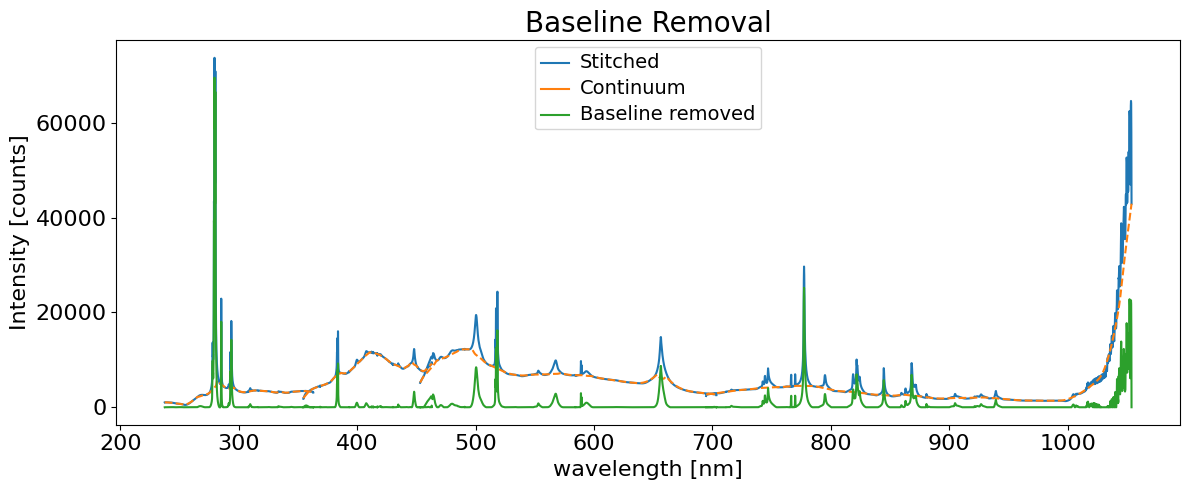

In [12]:
fig, ax = plot_spectra(
    [ws]*3,
    [stiched, continua, corrected],
    xlabel='wavelength [nm]',
    ylabel='Intensity [counts]',
    nombres=['Stitched','Continuum','Baseline removed'],
    titulo='Baseline Removal',
    no_show=True
)

# Cambiar la línea del continuum (índice 1) a discontínua
# ax.lines es una lista de Line2D en el orden que se graficaron
continuum_line = ax.lines[1]
continuum_line.set_linestyle('--')

# Ajustes de estilo generales
ax.set_title(ax.get_title(), fontsize=20)
ax.set_xlabel(ax.get_xlabel(), fontsize=16)
ax.set_ylabel(ax.get_ylabel(), fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=16)

leg = ax.get_legend()
if leg:
    for text in leg.get_texts():
        text.set_fontsize(14)
    leg.set_title(leg.get_title().get_text(), prop={'size':14})

# Finalmente mostrar
plt.tight_layout()
plt.show()


In [13]:
wls, normalized =apply_preprocessing(intensidades,ws)

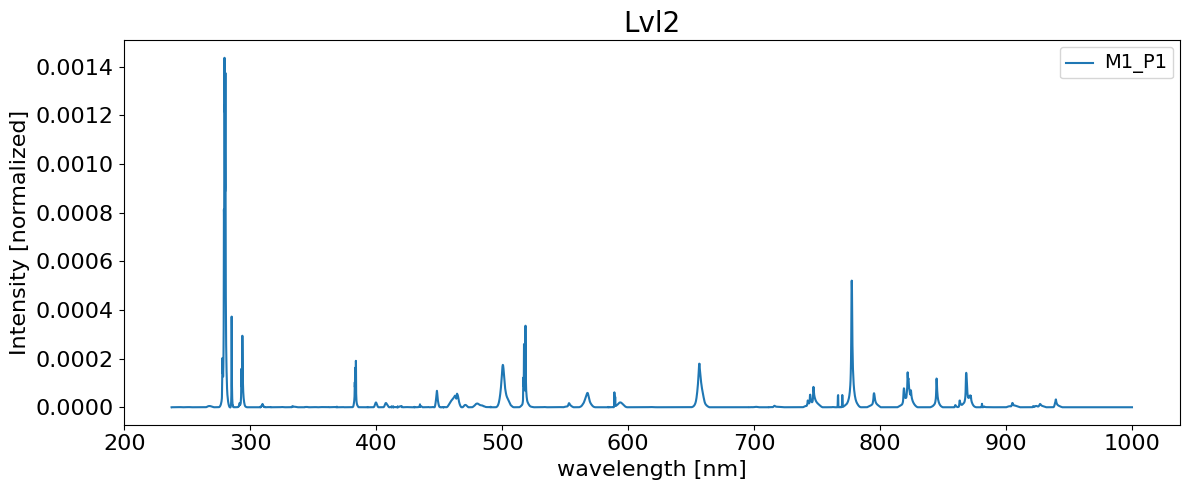

In [16]:
fig, ax = plot_spectra(wls, normalized, xlabel='wavelength [nm]',ylabel='Intensity [normalized]', titulo= 'Lvl2', nombres = ['M1_P1'], no_show = True)
# Título
ax.set_title(ax.get_title(), fontsize=20)

# Etiquetas de ejes
ax.set_xlabel(ax.get_xlabel(), fontsize=16)
ax.set_ylabel(ax.get_ylabel(), fontsize=16)

# Tamaño de los ticks
ax.tick_params(axis='both', which='major', labelsize=16)

# Leyenda
leg = ax.get_legend()
if leg:
    for text in leg.get_texts():
        text.set_fontsize(14)
    leg.set_title(leg.get_title().get_text(), prop={'size':14})
    
    # 1) Agarrar los datos X e Y ploteados
xdata = wls
ydata_orig = normalized

plt.tight_layout()
plt.show()